<a href="https://colab.research.google.com/github/bakerholic/Data-Analysis-with-Open-Source/blob/main/%ED%8C%8C%EC%9D%B4%EC%8D%AC6_7%EA%B0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import requests
url = "http://naver.com/abc"
response = requests.get(url)
print(response)

if response.status_code == 200 :
    data = response.json()
    print(data)
else :
    print("API non possilbe : ", response.status_code)


<Response [404]>
API non possilbe :  404


In [17]:
import requests
import json

url = 'http://apis.data.go.kr/1360000/SfcMtlyInfoService/getDailyWthrData'
params ={'serviceKey' : '0e7f17a7635374d0a66b8626de1b72a8d9b2eafb13c09830eebded6dfa33805a', 'pageNo' : '1', 'numOfRows' : '100', 'dataType' : 'json', 'year' : '2025', 'month' : '10' }
response = requests.get(url, params=params)
print(response)

response.encoding ='utf-8'
result = json.loads(response.text)
print(json.dumps(result, indent=2, ensure_ascii=False))


<Response [200]>
{
  "response": {
    "header": {
      "resultCode": "11",
      "resultMsg": "NO_MANDATORY_REQUEST_PARAMETERS_ERROR"
    }
  }
}


In [ ]:
import pandas as pd
item = result ['response'] ['body'] ['items']
df = pd.DataFrame(itesm)
print(df)

In [27]:
#7강 실습

import pandas as pd
import io
import requests

url = 'https://openmv.net/file/travel-times.csv'

# Adding a User-Agent header to mimic a web browser and avoid 403 Forbidden error
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

try:
    response = requests.get(url, headers=headers, stream=True)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    df = pd.read_csv(io.StringIO(response.text))
    print(df)
    print(df.info())
    print(df.head())
except requests.exceptions.HTTPError as e:
    print(f"Error fetching the file: {e}")
    print("The server might be blocking automated requests. Please check the URL manually or try downloading the file and uploading it to Colab.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


          Date StartTime  DayOfWeek GoingTo  Distance  MaxSpeed  AvgSpeed  \
0     1/6/2012     16:37     Friday    Home     51.29     127.4      78.3   
1     1/6/2012     08:20     Friday     GSK     51.63     130.3      81.8   
2     1/4/2012     16:17  Wednesday    Home     51.27     127.4      82.0   
3     1/4/2012     07:53  Wednesday     GSK     49.17     132.3      74.2   
4     1/3/2012     18:57    Tuesday    Home     51.15     136.2      83.4   
..         ...       ...        ...     ...       ...       ...       ...   
200  7/18/2011     08:09     Monday     GSK     54.52     125.6      49.9   
201  7/14/2011     08:03   Thursday     GSK     50.90     123.7      76.2   
202  7/13/2011     17:08  Wednesday    Home     51.96     132.6      57.5   
203  7/12/2011     17:51    Tuesday    Home     53.28     125.8      61.6   
204  7/11/2011     16:56     Monday    Home     51.73     125.0      62.8   

     AvgMovingSpeed FuelEconomy  TotalTime  MovingTime Take407All Comments 

In [32]:
print(df.isnull())
print(df.isnull().sum())
missing_ratio = df.isnull().mean()
print(missing_ratio)

      Date  StartTime  DayOfWeek  GoingTo  Distance  MaxSpeed  AvgSpeed  \
0    False      False      False    False     False     False     False   
1    False      False      False    False     False     False     False   
2    False      False      False    False     False     False     False   
3    False      False      False    False     False     False     False   
4    False      False      False    False     False     False     False   
..     ...        ...        ...      ...       ...       ...       ...   
200  False      False      False    False     False     False     False   
201  False      False      False    False     False     False     False   
202  False      False      False    False     False     False     False   
203  False      False      False    False     False     False     False   
204  False      False      False    False     False     False     False   

     AvgMovingSpeed  FuelEconomy  TotalTime  MovingTime  Take407All  Comments  
0             False

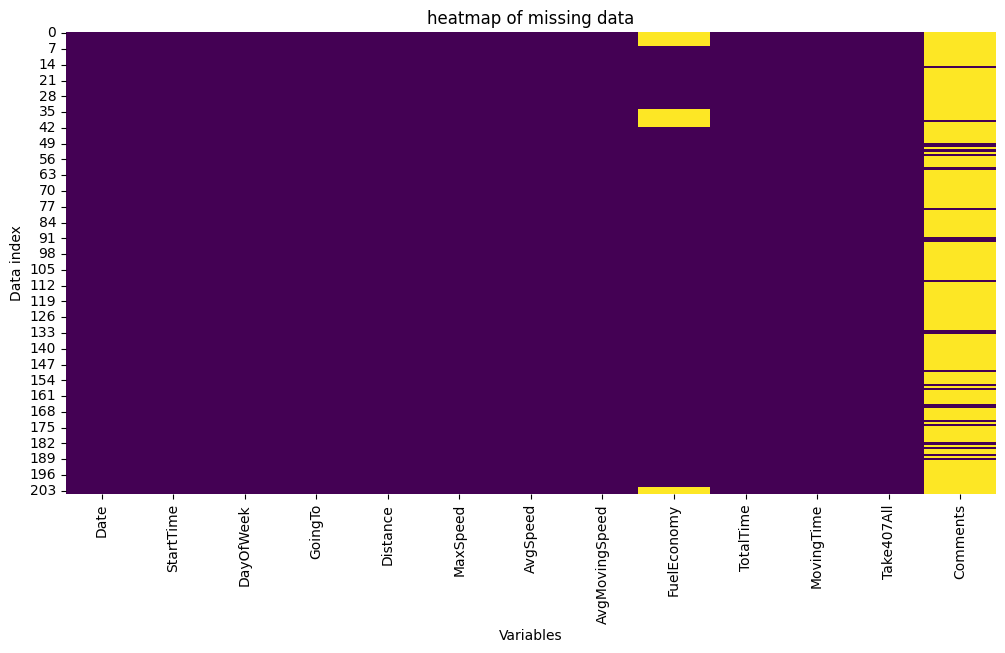

In [33]:
# 결측치 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.xlabel('Variables')
plt.ylabel('Data index')
plt.title('heatmap of missing data')
plt.show()

GridSpec(6, 6)

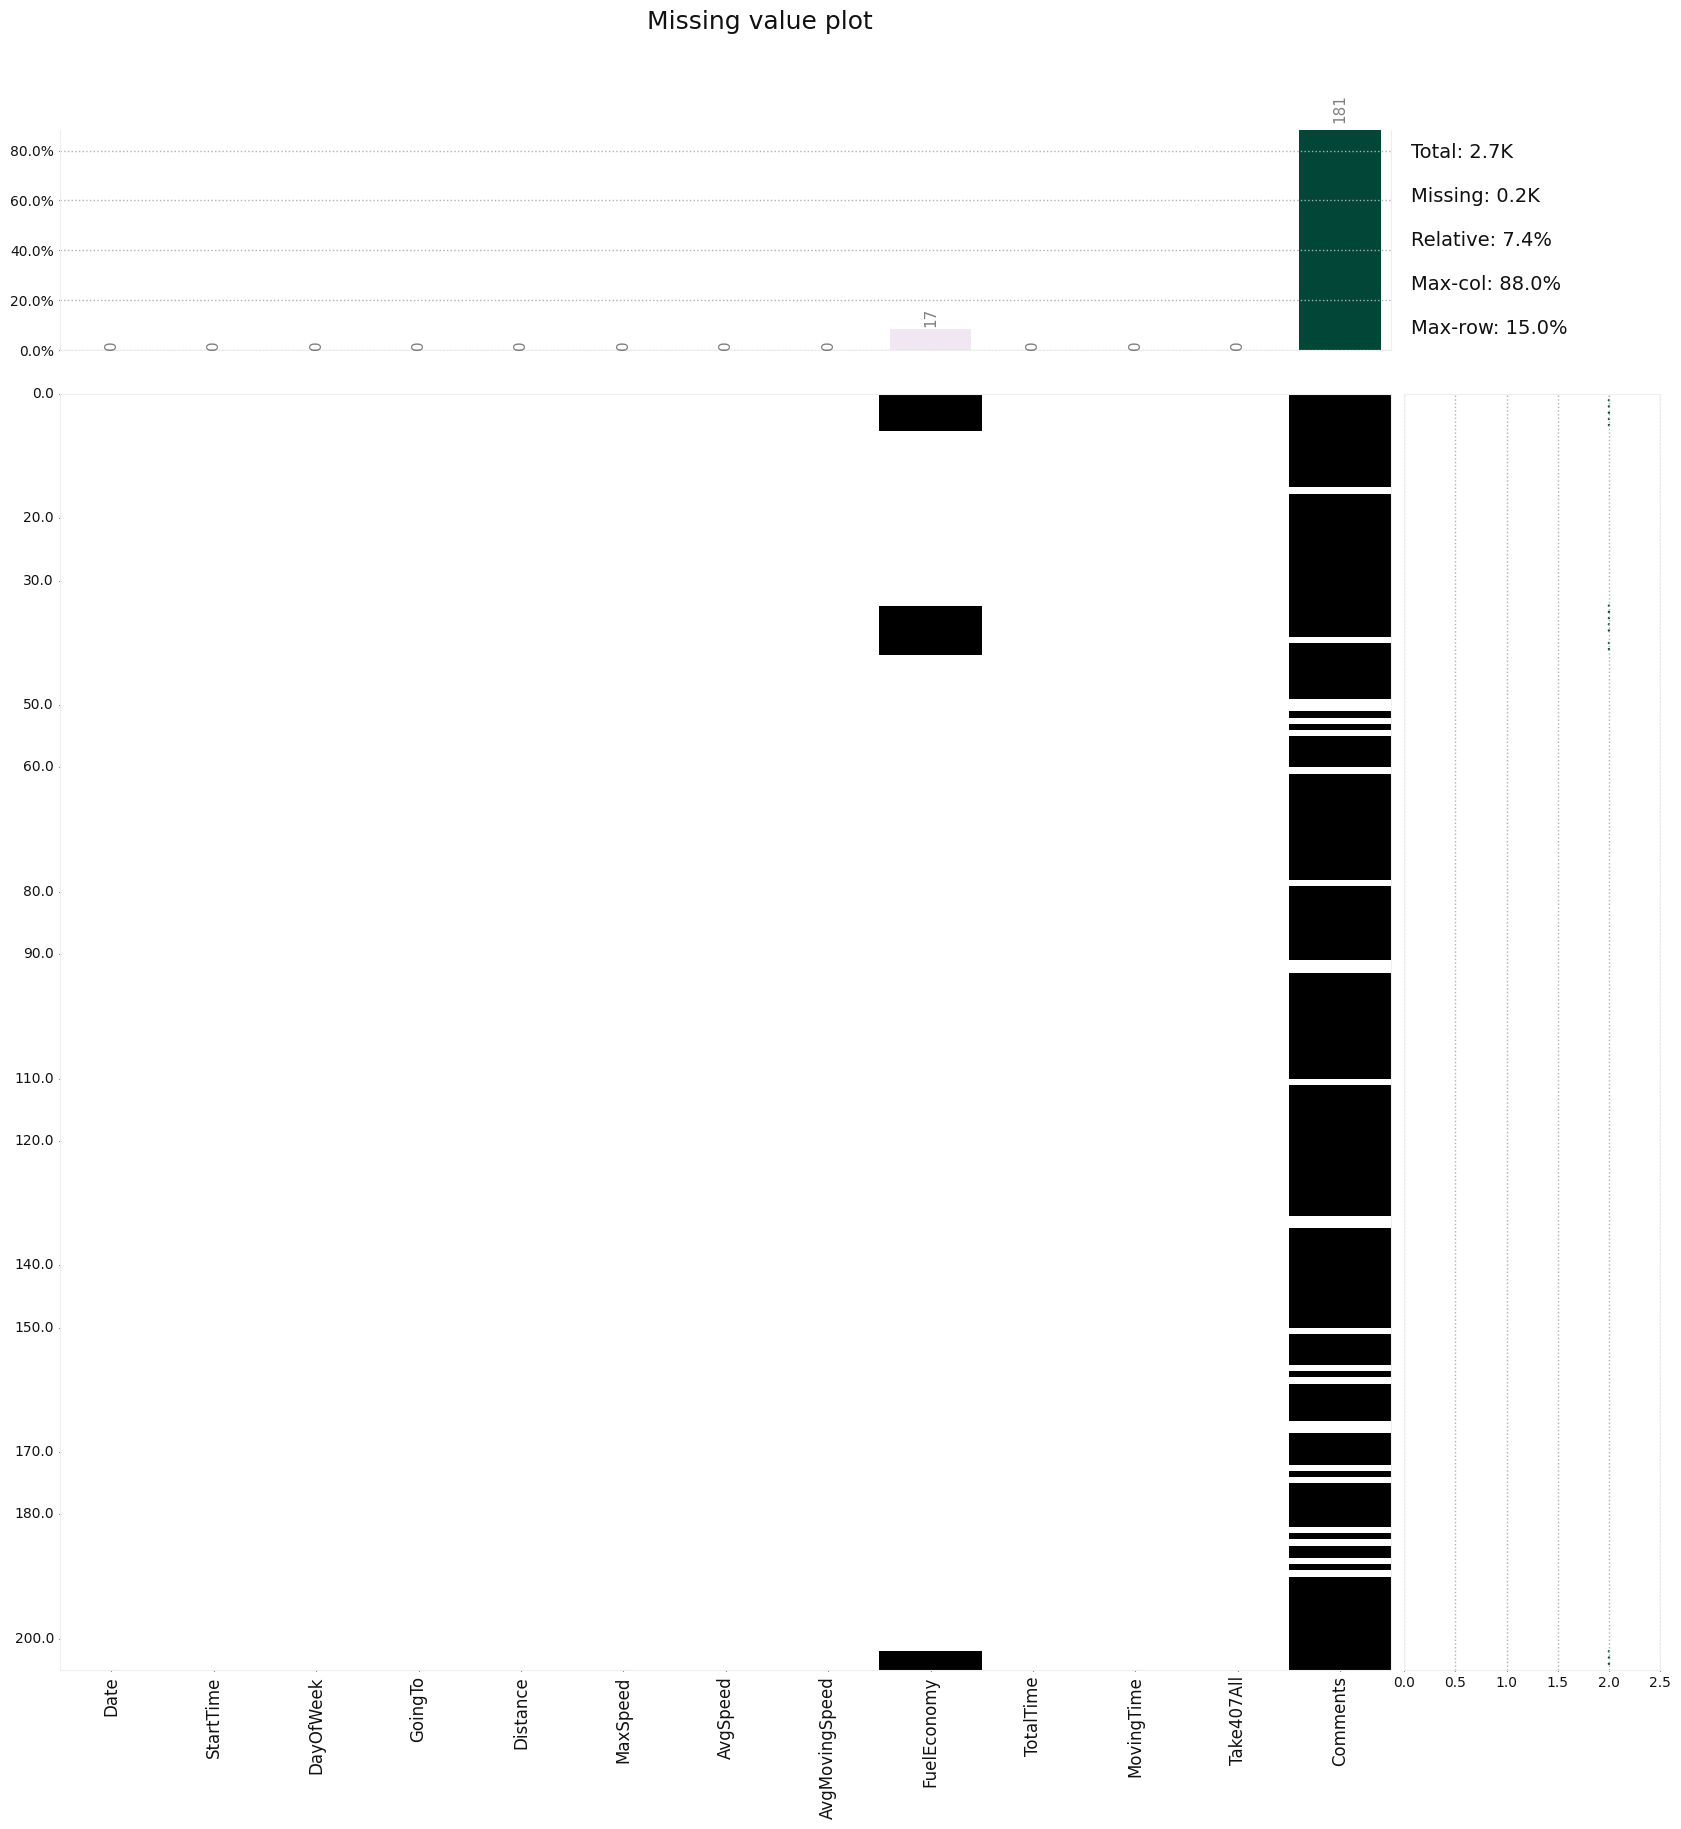

In [35]:
!pip install klib
import klib
klib.missingval_plot(df)

<Axes: title={'center': 'Feature-correlation (pearson)'}>

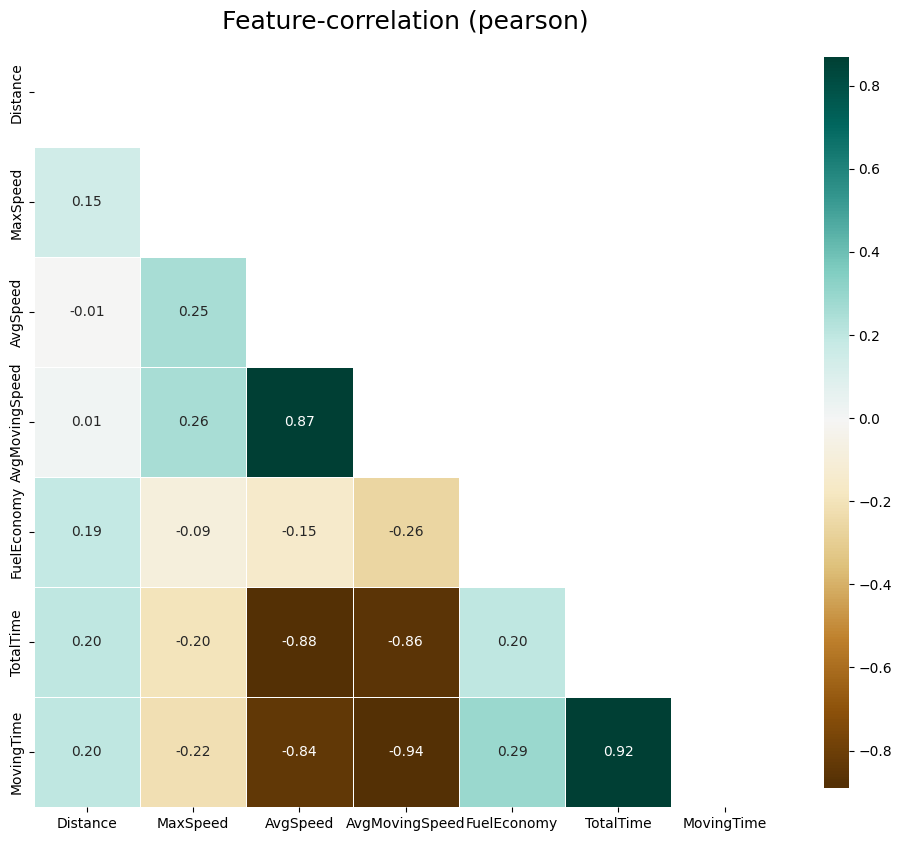

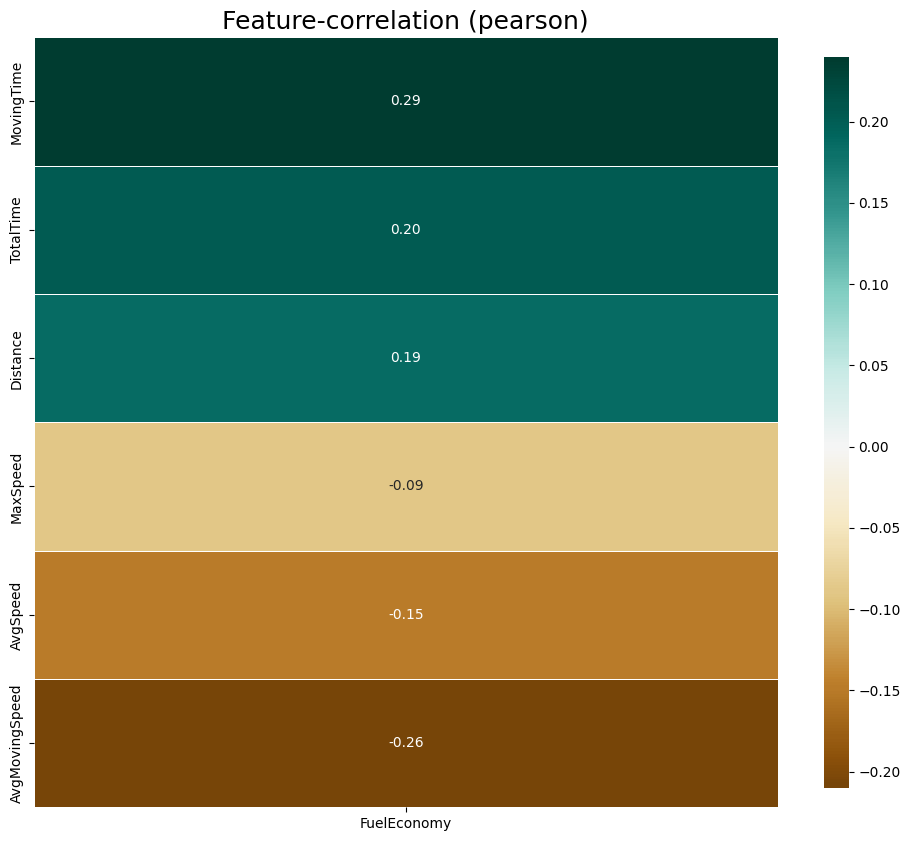

In [36]:
df['FuelEconomy'] = pd.to_numeric(df['FuelEconomy'], errors='coerce')

klib.corr_plot(df)
klib.corr_plot(df, target = 'FuelEconomy')